In [ ]:
!pip install pyspark


In [ ]:
import pyspark
print("PySpark Version:", pyspark.__version__)


PySpark Version: 3.5.3


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/weatherHistory.csv')
df.head(5)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [ ]:
# Number of rows
num_rows = df.count()

# Number of columns
num_columns = len(df.columns)

print(f"Dataset size: {num_rows} rows, {num_columns} columns")


Dataset size: 96453 rows, 12 columns


In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Load the dataset from Google Drive
df = pd.read_csv('/content/drive/MyDrive/weatherHistory.csv')

# Display the first 5 rows of the dataset
df.head(5)

# Number of rows before removing nulls and duplicates
num_rows_before = df.shape[0]

# Number of columns
num_columns = len(df.columns)

# Print dataset size before removing nulls and duplicates
print(f"Dataset size before removal: {num_rows_before} rows, {num_columns} columns")

# Check for null values in each column
print("\nNull values per column before preprocessing:")
print(df.isnull().sum())

# Remove rows with null values
df_cleaned = df.dropna()

# Remove duplicate rows
df_cleaned_no_duplicates = df_cleaned.drop_duplicates()

# Number of rows after removing nulls and duplicates
num_rows_after = df_cleaned_no_duplicates.shape[0]

# Print dataset size after removal
print(f"\nDataset size after removal: {num_rows_after} rows, {num_columns} columns")

# Check for null values again after cleaning
print("\nNull values per column after preprocessing:")
print(df_cleaned_no_duplicates.isnull().sum())

# Optional: Save the cleaned dataset without duplicates to Google Drive
df_cleaned_no_duplicates.to_csv('/content/drive/MyDrive/cleaned_weatherHistory_no_duplicates.csv', index=False)
print("\nCleaned dataset (without duplicates) saved as 'cleaned_weatherHistory_no_duplicates.csv'.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset size before removal: 96453 rows, 12 columns

Null values per column before preprocessing:
Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

Dataset size after removal: 95912 rows, 12 columns

Null values per column after preprocessing:
Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cove

In [ ]:
df.nunique()

,0
Formatted Date,96429
Summary,27
Precip Type,2
Temperature (C),7574
Apparent Temperature (C),8984
Humidity,90
Wind Speed (km/h),2484
Wind Bearing (degrees),360
Visibility (km),949
Loud Cover,1


In [ ]:
df.dtypes

,0
Formatted Date,object
Summary,object
Precip Type,object
Temperature (C),float64
Apparent Temperature (C),float64
Humidity,float64
Wind Speed (km/h),float64
Wind Bearing (degrees),float64
Visibility (km),float64
Loud Cover,float64


In [ ]:
from pyspark.sql import SparkSession

# Assuming spark is an existing SparkSession and df is a PySpark DataFrame
spark = SparkSession.builder.appName("Example").getOrCreate()

# Get DataFrame loaded into PySpark
df = spark.read.csv("/content/drive/MyDrive/weatherHistory.csv", header=True, inferSchema=True)

# Identify categorical and numerical columns
categorical_columns = [t[0] for t in df.dtypes if t[1] == 'string']
numerical_columns = [t[0] for t in df.dtypes if t[1] in ('float', 'double', 'int')]

print("Categorical Columns:", categorical_columns)
print("Numerical Columns:", numerical_columns)


Categorical Columns: ['Summary', 'Precip Type', 'Daily Summary']
Numerical Columns: ['Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)']


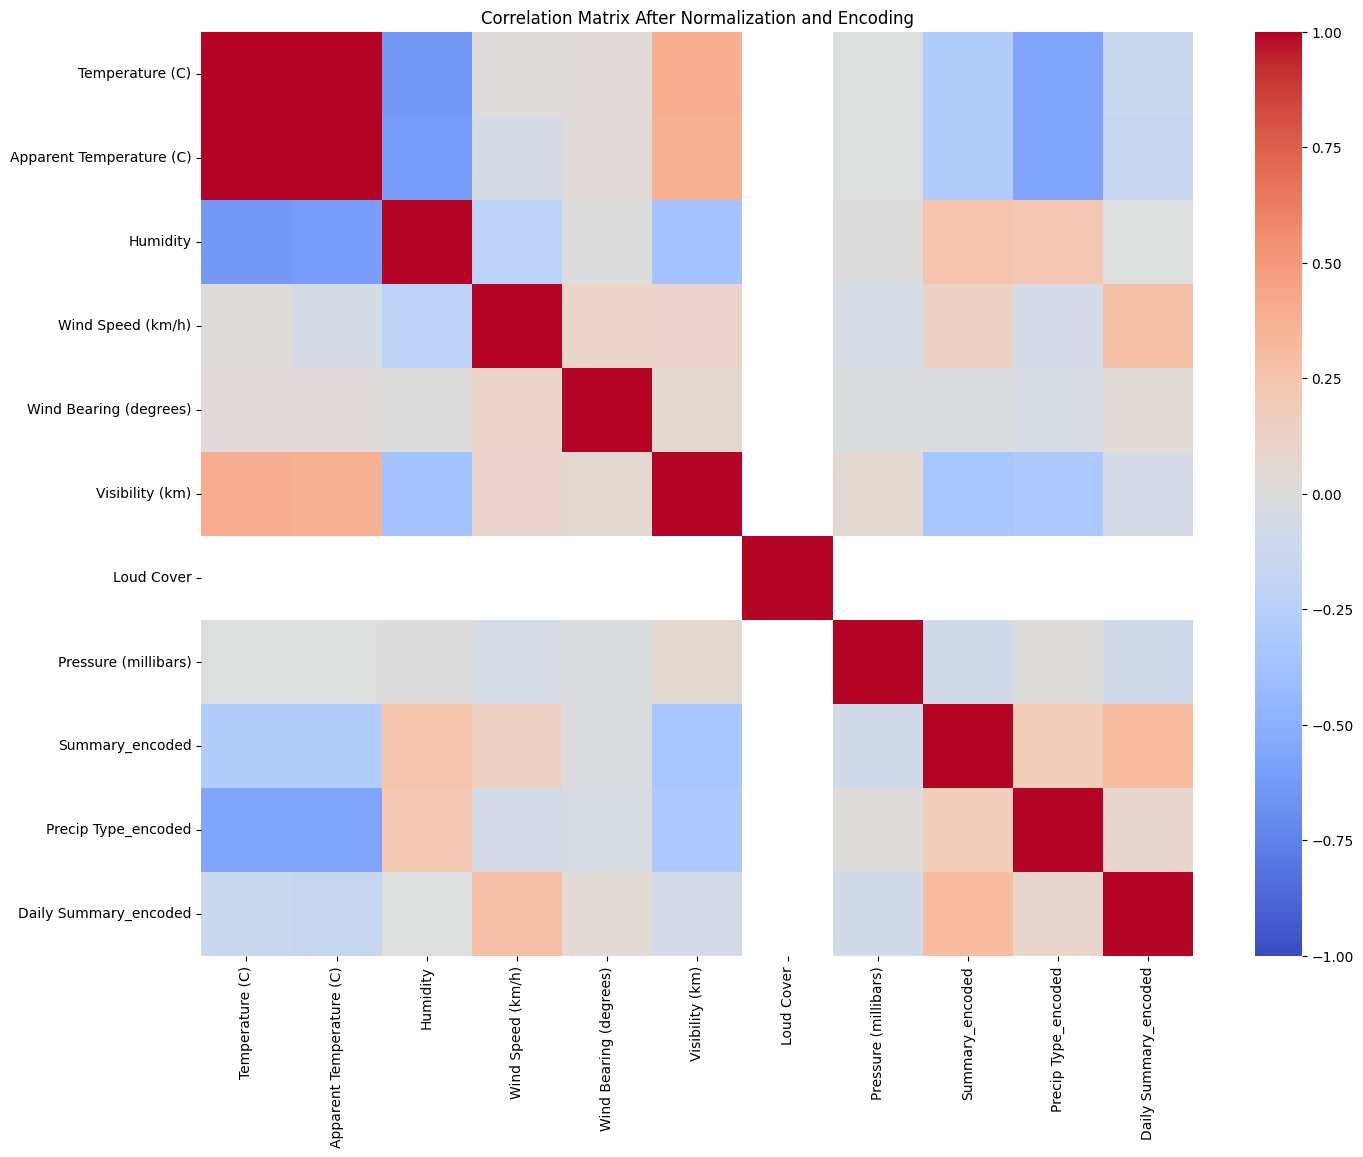

Unique Values in Encoded Columns:
Summary_encoded: 27
Precip Type_encoded: 2
Daily Summary_encoded: 214
                                     scaled_features
0  [-0.25794989368221083, -0.3240999764648619, 0....
1  [-0.2701399136956706, -0.33913206665628637, 0....
2  [-0.26781800512167836, -0.13853141479141437, 0...
3  [-0.3815915252473076, -0.4588704402500467, 0.4...
4  [-0.33283144519346686, -0.36245772384987585, 0...


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler
from pyspark.ml.stat import Correlation
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming Spark session is already initialized
spark = SparkSession.builder.appName('WeatherData').getOrCreate()

# Load the cleaned data (df_cleaned) from Pandas to PySpark DataFrame
# Assuming you already have df_cleaned from previous steps after removing nulls
df_cleaned_spark = spark.createDataFrame(df_cleaned)

# Drop unnecessary columns
columns_to_drop = [
    'Formatted Date'
]
merged_dataset = df_cleaned_spark.drop(*columns_to_drop)

# Define numerical and categorical columns
numerical_columns = [
    'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)'
]

categorical_columns = [
    'Summary', 'Precip Type', 'Daily Summary'
]

# Step 1: Label encoding for categorical columns
for col in categorical_columns:
    indexer = StringIndexer(inputCol=col, outputCol=f"{col}_encoded", handleInvalid="skip")
    merged_dataset = indexer.fit(merged_dataset).transform(merged_dataset)

# Rename encoded columns
encoded_columns = [f"{col}_encoded" for col in categorical_columns]
merged_dataset = merged_dataset.drop(*categorical_columns)

# Step 2: Assemble numerical and encoded features into a single vector column
all_features = numerical_columns + encoded_columns
assembler = VectorAssembler(inputCols=all_features, outputCol="features")
merged_dataset = assembler.transform(merged_dataset)

# Step 3: Standardize the features
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
merged_dataset = scaler.fit(merged_dataset).transform(merged_dataset)

# Step 4: Compute the correlation matrix
correlation_matrix = Correlation.corr(merged_dataset, "scaled_features").head()[0]
correlation_matrix = correlation_matrix.toArray()

# Convert the correlation matrix to a Pandas DataFrame for visualization
correlation_df = pd.DataFrame(correlation_matrix, columns=all_features, index=all_features)

# Plot the correlation matrix
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_df, annot=False, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix After Normalization and Encoding")
plt.show()

# Check column counts for validation
print("Unique Values in Encoded Columns:")
for col in encoded_columns:
    print(f"{col}: {merged_dataset.select(col).distinct().count()}")

# Convert PySpark DataFrame to Pandas for inspection (optional)
scaled_pandas_df = merged_dataset.select("scaled_features").toPandas()
print(scaled_pandas_df.head())


In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler
from pyspark.ml.classification import RandomForestClassifier  # Import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd

# Assuming Spark session is already created as 'spark'

# Load the cleaned data from Google Drive (after removing null values and duplicates)
df_cleaned = pd.read_csv('/content/drive/MyDrive/cleaned_weatherHistory_no_duplicates.csv')

# Convert the cleaned Pandas DataFrame to PySpark DataFrame
df_cleaned_spark = spark.createDataFrame(df_cleaned)

# Define and drop unnecessary columns
columns_to_drop = ['Formatted Date']
df_cleaned_spark = df_cleaned_spark.drop(*columns_to_drop)

# Define numerical and categorical columns
numerical_columns = [
    'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
    'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)'
]
categorical_columns = ['Summary', 'Precip Type', 'Daily Summary']

# Prepare stages for the pipeline
stages = []

# Label encoding for categorical columns
for col in categorical_columns:
    indexer = StringIndexer(inputCol=col, outputCol=f"{col}_encoded", handleInvalid="skip")
    stages.append(indexer)

# Assemble features into a vector
assembler = VectorAssembler(
    inputCols=numerical_columns + [f"{col}_encoded" for col in categorical_columns],
    outputCol="features")
stages.append(assembler)

# Standardize features
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
stages.append(scaler)

# Encode the target column ('Daily Summary')
label_indexer = StringIndexer(inputCol="Daily Summary", outputCol="label", handleInvalid="skip")
stages.append(label_indexer)

# Define the Random Forest Classifier
rf = RandomForestClassifier(labelCol="label", featuresCol="scaled_features", numTrees=10)  # Define RandomForest with 10 trees
stages.append(rf)

# Build the pipeline
pipeline = Pipeline(stages=stages)

# Split the data into train and test sets (80% training, 20% testing)
(train_data, test_data) = df_cleaned_spark.randomSplit([0.8, 0.2], seed=42)

# Train the model
model = pipeline.fit(train_data)

# Make predictions
predictions = model.transform(test_data)

# Evaluate the model using MulticlassClassificationEvaluator
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
precision = evaluator.evaluate(predictions)
print("Test Weighted Precision = %g" % precision)

recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
print("Test Weighted Recall = %g" % recall)

evaluator.setMetricName("accuracy")
accuracy = evaluator.evaluate(predictions)
print("Test Accuracy = %g" % accuracy)

evaluator.setMetricName("f1")
f1_score = evaluator.evaluate(predictions)
print("Test F1 Score = %g" % f1_score)


Test Weighted Precision = 0.440906
Test Weighted Recall = 0.50941
Test Accuracy = 0.50941
Test F1 Score = 0.4337


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score

# Load the cleaned data from CSV
df_cleaned = pd.read_csv('/content/drive/MyDrive/cleaned_weatherHistory_no_duplicates.csv')

# Drop unnecessary columns
columns_to_drop = ['Formatted Date']
df_cleaned = df_cleaned.drop(columns=columns_to_drop)

# Define numerical and categorical columns
numerical_columns = [
    'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
    'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)'
]
categorical_columns = ['Summary', 'Precip Type', 'Daily Summary']

# Encode categorical columns using LabelEncoder
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_cleaned[f"{col}_encoded"] = le.fit_transform(df_cleaned[col])
    label_encoders[col] = le  # Save encoder to use later if needed

# Prepare feature set (X) and target variable (y)
X = df_cleaned[numerical_columns + [f"{col}_encoded" for col in categorical_columns]]
y = df_cleaned['Daily Summary']  # Target variable

# Split the data into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=10, random_state=42)

# Train the model
rf.fit(X_train_scaled, y_train)

# Make predictions
y_pred = rf.predict(X_test_scaled)

# Overall evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print overall evaluation metrics
print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Overall Weighted Precision: {precision:.4f}")
print("Recall = ", recall_score(y_test, y_pred, average='weighted'))
print(f"Overall Weighted F1 Score: {f1:.4f}")


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Overall Accuracy: 0.9447
Overall Weighted Precision: 0.9442
Recall =  0.9446906114789136
Overall Weighted F1 Score: 0.9419


In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Assuming SparkSession is already created as 'spark' and DataFrame 'df' is loaded

# Define and drop unnecessary columns
columns_to_drop = ['Formatted Date']
df = df.drop(*columns_to_drop)

# Define numerical and categorical columns
numerical_columns = [
    'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
    'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)'
]
categorical_columns = ['Summary', 'Precip Type', 'Daily Summary']

# Prepare stages for the pipeline
stages = []

# Label encoding for categorical columns
for col in categorical_columns:
    indexer = StringIndexer(inputCol=col, outputCol=f"{col}_encoded", handleInvalid="keep")
    stages.append(indexer)

# Assemble features into a vector
assembler = VectorAssembler(
    inputCols=numerical_columns + [f"{col}_encoded" for col in categorical_columns],
    outputCol="features")
stages.append(assembler)

# Standardize features
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
stages.append(scaler)

# Encode the target column
label_indexer = StringIndexer(inputCol="Daily Summary", outputCol="label", handleInvalid="keep")
stages.append(label_indexer)

# Define the Decision Tree Classifier
dt = DecisionTreeClassifier(labelCol="label", featuresCol="scaled_features")
stages.append(dt)

# Build the pipeline
pipeline = Pipeline(stages=stages)

# Split the data
(train_data, test_data) = df.randomSplit([0.8, 0.2], seed=42)

# Train the model
model = pipeline.fit(train_data)

# Make predictions
predictions = model.transform(test_data)

# Evaluate the model using MulticlassClassificationEvaluator
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
precision = evaluator.evaluate(predictions)
print("Test Weighted Precision = %g" % precision)

recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
print("Test Weighted Recall = %g" % recall)

evaluator.setMetricName("accuracy")
accuracy = evaluator.evaluate(predictions)
print("Test Accuracy = %g" % accuracy)

evaluator.setMetricName("f1")
f1_score = evaluator.evaluate(predictions)
print("Test F1 Score = %g" % f1_score)




Test Weighted Precision = 0.47598
Test Weighted Recall = 0.510931
Test Accuracy = 0.510931
Test F1 Score = 0.478311


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score,recall_score

# Load the cleaned data from CSV
df_cleaned = pd.read_csv('/content/drive/MyDrive/cleaned_weatherHistory_no_duplicates.csv')

# Drop unnecessary columns
columns_to_drop = ['Formatted Date']
df_cleaned = df_cleaned.drop(columns=columns_to_drop)

# Define numerical and categorical columns
numerical_columns = [
    'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
    'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)'
]
categorical_columns = ['Summary', 'Precip Type', 'Daily Summary']

# Encode categorical columns using LabelEncoder
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_cleaned[f"{col}_encoded"] = le.fit_transform(df_cleaned[col])
    label_encoders[col] = le  # Save encoder to use later if needed

# Prepare feature set (X) and target variable (y)
X = df_cleaned[numerical_columns + [f"{col}_encoded" for col in categorical_columns]]
y = df_cleaned['Daily Summary']  # Target variable

# Split the data into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)

# Train the model
dt.fit(X_train_scaled, y_train)

# Make predictions
y_pred = dt.predict(X_test_scaled)

# Evaluate the model with overall metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')  # weighted for overall precision
f1 = f1_score(y_test, y_pred, average='weighted')  # weighted for overall F1 score

# Output the overall evaluation metrics
print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Overall Weighted Precision: {precision:.4f}")
print("Recall = ", recall_score(y_test, y_pred, average='weighted'))
print(f"Overall Weighted F1 Score: {f1:.4f}")


Overall Accuracy: 0.9998
Overall Weighted Precision: 0.9998
Recall =  0.9997914820413908
Overall Weighted F1 Score: 0.9998


In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler
from pyspark.ml.classification import MultilayerPerceptronClassifier  # Import MLP
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd

# Initialize Spark session
spark = SparkSession.builder.appName("WeatherClassification").getOrCreate()

# Load the cleaned data from Google Drive (after removing null values and duplicates)
df_cleaned = pd.read_csv('/content/drive/MyDrive/cleaned_weatherHistory_no_duplicates.csv')

# Convert the cleaned Pandas DataFrame to PySpark DataFrame
df_cleaned_spark = spark.createDataFrame(df_cleaned)

# Define and drop unnecessary columns
columns_to_drop = ['Formatted Date']
df_cleaned_spark = df_cleaned_spark.drop(*columns_to_drop)

# Define numerical and categorical columns
numerical_columns = [
    'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
    'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)'
]
categorical_columns = ['Summary', 'Precip Type', 'Daily Summary']

# Prepare stages for the pipeline
stages = []

# Label encoding for categorical columns
for col in categorical_columns:
    indexer = StringIndexer(inputCol=col, outputCol=f"{col}_encoded", handleInvalid="skip")
    stages.append(indexer)

# Assemble features into a vector
assembler = VectorAssembler(
    inputCols=numerical_columns + [f"{col}_encoded" for col in categorical_columns],
    outputCol="features")
stages.append(assembler)

# Standardize features
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
stages.append(scaler)

# Encode the target column ('Daily Summary')
label_indexer = StringIndexer(inputCol="Daily Summary", outputCol="label", handleInvalid="skip")
stages.append(label_indexer)

# Define the Multilayer Perceptron Classifier
# Define the layers: input layer, hidden layers, and output layer
layers = [len(numerical_columns) + len(categorical_columns), 128, 64, len(df_cleaned_spark.select('Daily Summary').distinct().collect())]  # Example layers: 128, 64 neurons in hidden layers
mlp = MultilayerPerceptronClassifier(layers=layers, labelCol="label", featuresCol="scaled_features", maxIter=100)
stages.append(mlp)

# Build the pipeline
pipeline = Pipeline(stages=stages)

# Split the data into train and test sets (80% training, 20% testing)
(train_data, test_data) = df_cleaned_spark.randomSplit([0.8, 0.2], seed=42)

# Train the model
model = pipeline.fit(train_data)

# Make predictions
predictions = model.transform(test_data)

# Evaluate the model using MulticlassClassificationEvaluator
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
precision = evaluator.evaluate(predictions)
print("Test Weighted Precision = %g" % precision)

recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
print("Test Weighted Recall = %g" % recall)

evaluator.setMetricName("accuracy")
accuracy = evaluator.evaluate(predictions)
print("Test Accuracy = %g" % accuracy)

evaluator.setMetricName("f1")
f1_score = evaluator.evaluate(predictions)
print("Test F1 Score = %g" % f1_score)


Test Weighted Precision = 0.799844
Test Weighted Recall = 0.810957
Test Accuracy = 0.810957
Test F1 Score = 0.798422


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score,recall_score

# Load the cleaned data from CSV
df_cleaned = pd.read_csv('/content/drive/MyDrive/cleaned_weatherHistory_no_duplicates.csv')

# Drop unnecessary columns
columns_to_drop = ['Formatted Date']
df_cleaned = df_cleaned.drop(columns=columns_to_drop)

# Define numerical and categorical columns
numerical_columns = [
    'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
    'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)'
]
categorical_columns = ['Summary', 'Precip Type', 'Daily Summary']

# Encode categorical columns using LabelEncoder
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_cleaned[f"{col}_encoded"] = le.fit_transform(df_cleaned[col])
    label_encoders[col] = le  # Save encoder to use later if needed

# Prepare feature set (X) and target variable (y)
X = df_cleaned[numerical_columns + [f"{col}_encoded" for col in categorical_columns]]
y = df_cleaned['Daily Summary']  # Target variable

# Split the data into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the Multilayer Perceptron Classifier (MLP)
mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=100, random_state=42)

# Train the model
mlp.fit(X_train_scaled, y_train)

# Make predictions
y_pred = mlp.predict(X_test_scaled)

# Evaluate the model with overall metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')  # weighted for overall precision
f1 = f1_score(y_test, y_pred, average='weighted')  # weighted for overall F1 score

# Output the overall evaluation metrics
print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Overall Weighted Precision: {precision:.4f}")
print("Recall = ", recall_score(y_test, y_pred, average='weighted'))
print(f"Overall Weighted F1 Score: {f1:.4f}")


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Overall Accuracy: 0.9540
Overall Weighted Precision: 0.9575
Recall =  0.9540217901266747
Overall Weighted F1 Score: 0.9493


In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler
from pyspark.ml.classification import LogisticRegression  # Import Logistic Regression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd

# Initialize Spark session
spark = SparkSession.builder.appName("WeatherClassification").getOrCreate()

# Load the cleaned data from Google Drive (after removing null values and duplicates)
df_cleaned = pd.read_csv('/content/drive/MyDrive/cleaned_weatherHistory_no_duplicates.csv')

# Convert the cleaned Pandas DataFrame to PySpark DataFrame
df_cleaned_spark = spark.createDataFrame(df_cleaned)

# Define and drop unnecessary columns
columns_to_drop = ['Formatted Date']
df_cleaned_spark = df_cleaned_spark.drop(*columns_to_drop)

# Define numerical and categorical columns
numerical_columns = [
    'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
    'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)'
]
categorical_columns = ['Summary', 'Precip Type', 'Daily Summary']

# Prepare stages for the pipeline
stages = []

# Label encoding for categorical columns
for col in categorical_columns:
    indexer = StringIndexer(inputCol=col, outputCol=f"{col}_encoded", handleInvalid="skip")
    stages.append(indexer)

# Assemble features into a vector
assembler = VectorAssembler(
    inputCols=numerical_columns + [f"{col}_encoded" for col in categorical_columns],
    outputCol="features")
stages.append(assembler)

# Standardize features
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
stages.append(scaler)

# Encode the target column ('Daily Summary')
label_indexer = StringIndexer(inputCol="Daily Summary", outputCol="label", handleInvalid="skip")
stages.append(label_indexer)

# Define the Logistic Regression model
lr = LogisticRegression(labelCol="label", featuresCol="scaled_features", maxIter=100)
stages.append(lr)

# Build the pipeline
pipeline = Pipeline(stages=stages)

# Split the data into train and test sets (80% training, 20% testing)
(train_data, test_data) = df_cleaned_spark.randomSplit([0.8, 0.2], seed=42)

# Train the model
model = pipeline.fit(train_data)

# Make predictions
predictions = model.transform(test_data)

# Evaluate the model using MulticlassClassificationEvaluator
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
precision = evaluator.evaluate(predictions)
print("Test Weighted Precision = %g" % precision)

recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
print("Test Weighted Recall = %g" % recall)

evaluator.setMetricName("accuracy")
accuracy = evaluator.evaluate(predictions)
print("Test Accuracy = %g" % accuracy)

evaluator.setMetricName("f1")
f1_score = evaluator.evaluate(predictions)
print("Test F1 Score = %g" % f1_score)


Test Weighted Precision = 0.750784
Test Weighted Recall = 0.749515
Test Accuracy = 0.749515
Test F1 Score = 0.746142


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score

# Load the cleaned data from CSV
df_cleaned = pd.read_csv('/content/drive/MyDrive/cleaned_weatherHistory_no_duplicates.csv')

# Drop unnecessary columns
columns_to_drop = ['Formatted Date']
df_cleaned = df_cleaned.drop(columns=columns_to_drop)

# Define numerical and categorical columns
numerical_columns = [
    'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
    'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)'
]
categorical_columns = ['Summary', 'Precip Type', 'Daily Summary']

# Encode categorical columns using LabelEncoder
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_cleaned[f"{col}_encoded"] = le.fit_transform(df_cleaned[col])
    label_encoders[col] = le  # Save encoder to use later if needed

# Prepare feature set (X) and target variable (y)
X = df_cleaned[numerical_columns + [f"{col}_encoded" for col in categorical_columns]]
y = df_cleaned['Daily Summary']  # Target variable

# Split the data into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the Logistic Regression model
lr = LogisticRegression(max_iter=100, random_state=42)

# Train the model
lr.fit(X_train_scaled, y_train)

# Make predictions
y_pred = lr.predict(X_test_scaled)

# Evaluate the model using overall evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print overall evaluation metrics
print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Overall Weighted Precision: {precision:.4f}")
print("Recall = ", recall_score(y_test, y_pred, average='weighted'))
print(f"Overall Weighted F1 Score: {f1:.4f}")




/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Overall Accuracy: 0.5694
Overall Weighted Precision: 0.4537
Recall =  0.5694104154720325
Overall Weighted F1 Score: 0.4729


In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, MinMaxScaler
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("Naive Bayes Example") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

# Load the cleaned data from Google Drive (after removing null values and duplicates)
df_cleaned = pd.read_csv('/content/drive/MyDrive/cleaned_weatherHistory_no_duplicates.csv')

# Convert the cleaned Pandas DataFrame to PySpark DataFrame
df = spark.createDataFrame(df_cleaned)

# Define and drop unnecessary columns
columns_to_drop = ['Formatted Date']
df = df.drop(*columns_to_drop)

# Define numerical and categorical columns
numerical_columns = [
    'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
    'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)'
]
categorical_columns = ['Summary', 'Precip Type', 'Daily Summary']

# Prepare stages for the pipeline
stages = []

# Label encoding for categorical columns
for col in categorical_columns:
    indexer = StringIndexer(inputCol=col, outputCol=f"{col}_encoded", handleInvalid="skip")
    stages.append(indexer)

# Assemble features into a vector
assembler = VectorAssembler(
    inputCols=[col for col in numerical_columns] + [f"{col}_encoded" for col in categorical_columns],
    outputCol="raw_features")
stages.append(assembler)

# Scale features using MinMaxScaler to ensure all features are non-negative
scaler = MinMaxScaler(inputCol="raw_features", outputCol="features")
stages.append(scaler)

# Encode the target column ('Daily Summary')
label_indexer = StringIndexer(inputCol="Daily Summary", outputCol="label", handleInvalid="skip")
stages.append(label_indexer)

# Define the Naive Bayes Classifier
nb = NaiveBayes(labelCol="label", featuresCol="features", modelType="multinomial")
stages.append(nb)

# Build the pipeline
pipeline = Pipeline(stages=stages)

# Split the data into training and test sets
(train_data, test_data) = df.randomSplit([0.8, 0.2], seed=42)

# Train the model
model = pipeline.fit(train_data)

# Make predictions
predictions = model.transform(test_data)

# Evaluate the model using MulticlassClassificationEvaluator for precision, accuracy, and F1 score
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Calculate and print evaluation metrics
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
print("Test Weighted Precision = %g" % precision)

recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
print("Test Weighted Recall = %g" % recall)

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
print("Test Accuracy = %g" % accuracy)

f1_score = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})
print("Test F1 Score = %g" % f1_score)


Test Weighted Precision = 0.0535256
Test Weighted Recall = 0.213735
Test Accuracy = 0.213735
Test F1 Score = 0.0854717


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, precision_score, f1_score,recall_score

# Load the cleaned data from CSV
df_cleaned = pd.read_csv('/content/drive/MyDrive/cleaned_weatherHistory_no_duplicates.csv')

# Drop unnecessary columns
columns_to_drop = ['Formatted Date']
df_cleaned = df_cleaned.drop(columns=columns_to_drop)

# Define numerical and categorical columns
numerical_columns = [
    'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
    'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)'
]
categorical_columns = ['Summary', 'Precip Type', 'Daily Summary']

# Encode categorical columns using LabelEncoder
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_cleaned[f"{col}_encoded"] = le.fit_transform(df_cleaned[col])
    label_encoders[col] = le  # Save encoder to use later if needed

# Prepare feature set (X) and target variable (y)
X = df_cleaned[numerical_columns + [f"{col}_encoded" for col in categorical_columns]]
y = df_cleaned['Daily Summary']  # Target variable

# Split the data into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the Naive Bayes Classifier (Multinomial)
nb = MultinomialNB()

# Train the model
nb.fit(X_train_scaled, y_train)

# Make predictions
y_pred = nb.predict(X_test_scaled)

# Evaluate the model

print("Accuracy = ", accuracy_score(y_test, y_pred))
print("Precision = ", precision_score(y_test, y_pred, average='weighted'))
print("Recall = ", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score = ", f1_score(y_test, y_pred, average='weighted'))


Accuracy =  0.2062242610644842


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Precision =  0.04252844585159253
Recall =  0.2062242610644842
F1 Score =  0.07051498999706983
